# 02 — Constituency Analysis
**Ubon Ratchathani Constituency 10** | Data Science Project 2025/2

This notebook:
1. Total scores per candidate (overall winner)
2. Scores by amphoe — who won where
3. Scores by tambon — granular breakdown
4. Margin of victory per amphoe
5. Vote share % per candidate

## 0 · Imports & Config

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

RAW = Path('../data-final')
OUT = Path('../data-processed/2')
OUT1 = Path('../data-processed/1')
FIG = Path('../figures')
FIG.mkdir(parents=True, exist_ok=True)

# Load processed data from notebook 01
df_const        = pd.read_csv(OUT1 / 'constituency_station.csv')
const_by_amphoe = pd.read_csv(OUT1 / 'constituency_by_amphoe.csv')
const_by_tambon = pd.read_csv(OUT1 / 'constituency_by_tambon.csv')
cand_map        = pd.read_csv(OUT1 / 'candidate_mapping.csv')

# Candidate color palette dict  {party_name: hex}
color_map = dict(zip(cand_map['party_name'], cand_map['color_hex']))
OUT.mkdir(parents=True, exist_ok=True)

print('Loaded OK')
df_const.head(2)

Loaded OK


,station_name,amphoe,tambon,station_id,station_type,cand_number,candidate_name,party_name,color_hex,score
0,election_data\ล่วงหน้านอกเขตเลือกตั้งและนอกราช...,ล่วงหน้านอกเขต,ล่วงหน้านอกเขต,ส.ส.5-17 ชุดที่ 9,advance_out,1,นายเกษม ฉิมพลี,ภูมิใจไทย,#212b6b,36
1,election_data\ล่วงหน้านอกเขตเลือกตั้งและนอกราช...,ล่วงหน้านอกเขต,ล่วงหน้านอกเขต,ส.ส.5-17 ชุดที่ 9,advance_out,2,นายสมศักดิ์ บุญประชม,เพื่อไทรวมพลัง,#ff66cc,257


In [18]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Use a font that supports Thai — try system fonts first
thai_fonts = ['Tahoma', 'Arial Unicode MS', 'Noto Sans Thai', 'TH Sarabun New', 'FreeSans']

available = [f.name for f in fm.fontManager.ttflist]
chosen = next((f for f in thai_fonts if f in available), None)

if chosen:
    plt.rcParams['font.family'] = chosen
    print(f'Using font: {chosen}')
else:
    print('No Thai font found — labels may be garbled')
    print('Available fonts sample:', available[:10])

Using font: Tahoma


## 1 · Overall Winner

In [19]:
total = (
    df_const
    .groupby(['cand_number', 'candidate_name', 'party_name', 'color_hex'])['score']
    .sum()
    .reset_index()
    .sort_values('score', ascending=False)
)

total['vote_share_%'] = (total['score'] / total['score'].sum() * 100).round(2)
total['rank'] = range(1, len(total) + 1)

print('=== Overall Result ===')
print(total[['rank', 'cand_number', 'candidate_name', 'party_name', 'score', 'vote_share_%']]
      .to_string(index=False))

=== Overall Result ===
 rank  cand_number          candidate_name     party_name  score  vote_share_%
    1            2    นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง  60543         80.41
    2            3       นายวัชรพล เชื้อคง       เพื่อไทย   5647          7.50
    3            5    นายสิโรตม์ แสนทวีสุข        ประชาชน   4849          6.44
    4            1          นายเกษม ฉิมพลี      ภูมิใจไทย   3111          4.13
    5            4 นางสาวมิลิณ กำเนิดสิงห์   พลังประชารัฐ    887          1.18
    6            6            นายยิ่ง ภูผา   ประชาธิปัตย์    255          0.34


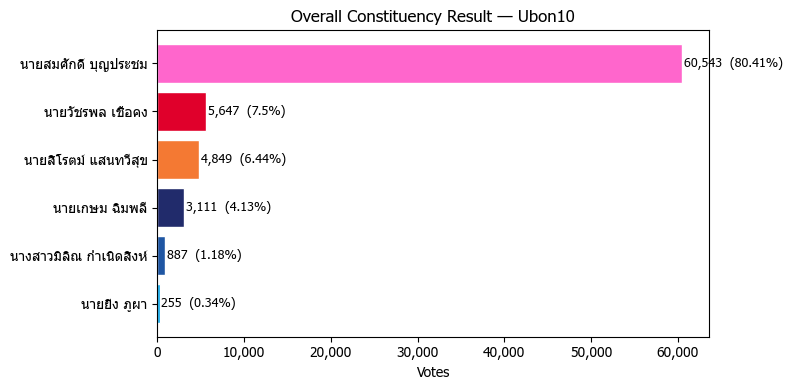

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.barh(
    total['candidate_name'],
    total['score'],
    color=total['color_hex'],
    edgecolor='white'
)

# Annotate score + %
for bar, (_, row) in zip(bars, total.iterrows()):
    ax.text(
        bar.get_width() + 200,
        bar.get_y() + bar.get_height() / 2,
        f"{row['score']:,}  ({row['vote_share_%']}%)",
        va='center', fontsize=9
    )

ax.set_xlabel('Votes')
ax.set_title('Overall Constituency Result — Ubon10')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG / 'overall_constituency.png', dpi=150)
plt.show()

## 2 · Scores by Amphoe

In [21]:
# Winner per amphoe
winner_per_amphoe = (
    const_by_amphoe
    .sort_values('score', ascending=False)
    .groupby('amphoe')
    .first()
    .reset_index()
    [['amphoe', 'cand_number', 'candidate_name', 'party_name', 'score', 'color_hex']]
)

print('=== Winner per Amphoe ===')
print(winner_per_amphoe[['amphoe', 'candidate_name', 'party_name', 'score']].to_string(index=False))

=== Winner per Amphoe ===
          amphoe       candidate_name     party_name  score
  ล่วงหน้านอกเขต นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง   4659
อำเภอทุ่งศรีอุดม นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง  10136
    อำเภอน้ำขุ่น นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง  10171
     อำเภอน้ำยืน นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง  25904
      อำเภอสำโรง นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง   9673


In [22]:
# Vote share % within each amphoe
amphoe_total = const_by_amphoe.groupby('amphoe')['score'].sum().rename('amphoe_total')
const_by_amphoe = const_by_amphoe.merge(amphoe_total, on='amphoe')
const_by_amphoe['vote_share_%'] = (
    const_by_amphoe['score'] / const_by_amphoe['amphoe_total'] * 100
).round(2)

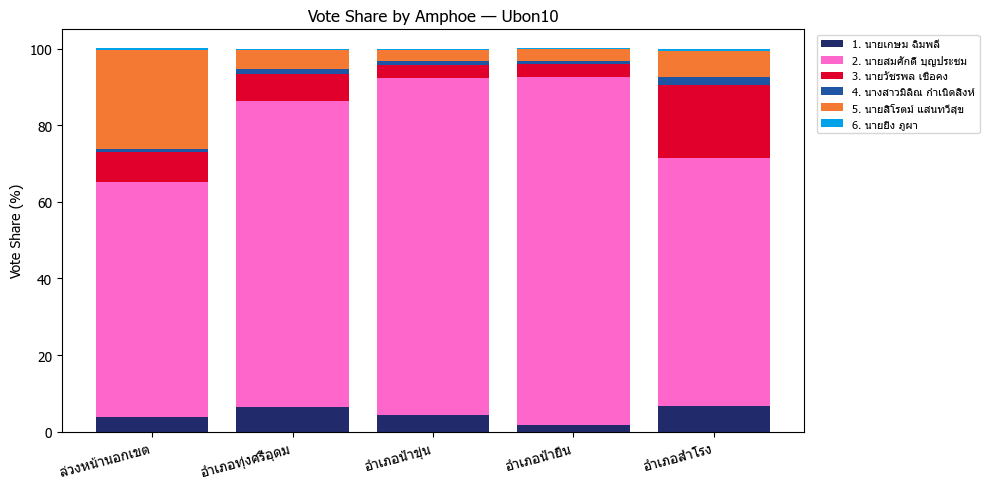

In [23]:
# Stacked bar — vote share by amphoe
amphoes = const_by_amphoe['amphoe'].unique()
cands   = total.sort_values('cand_number')['candidate_name'].tolist()

fig, ax = plt.subplots(figsize=(10, 5))

cands_df = total.sort_values('cand_number')
bottoms  = {a: 0 for a in amphoes}

for _, crow in cands_df.iterrows():
    cname  = crow['candidate_name']
    color  = crow['color_hex']
    shares = []
    for amp in amphoes:
        row = const_by_amphoe[
            (const_by_amphoe['amphoe'] == amp) &
            (const_by_amphoe['candidate_name'] == cname)
        ]
        shares.append(row['vote_share_%'].values[0] if len(row) else 0)

    ax.bar(amphoes, shares, bottom=[bottoms[a] for a in amphoes],
           color=color, label=f"{crow['cand_number']}. {cname}")
    for i, amp in enumerate(amphoes):
        bottoms[amp] += shares[i]

ax.set_ylabel('Vote Share (%)')
ax.set_title('Vote Share by Amphoe — Ubon10')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(FIG / 'vote_share_by_amphoe.png', dpi=150)
plt.show()

## 3 · Scores by Tambon

In [24]:
# Winner per tambon
winner_per_tambon = (
    const_by_tambon
    .sort_values('score', ascending=False)
    .groupby(['amphoe', 'tambon'])
    .first()
    .reset_index()
    [['amphoe', 'tambon', 'candidate_name', 'party_name', 'score', 'color_hex']]
)

print('=== Winner per Tambon ===')
print(winner_per_tambon.to_string(index=False))

=== Winner per Tambon ===
          amphoe          tambon       candidate_name     party_name  score color_hex
  ล่วงหน้านอกเขต  ล่วงหน้านอกเขต นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง   4659   #ff66cc
อำเภอทุ่งศรีอุดม     ตำบลกุดเรือ นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง   2389   #ff66cc
อำเภอทุ่งศรีอุดม      ตำบลนาห่อม นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง   1554   #ff66cc
อำเภอทุ่งศรีอุดม      ตำบลนาเกษม นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง   1957   #ff66cc
อำเภอทุ่งศรีอุดม     ตำบลหนองอ้ม นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง   1919   #ff66cc
อำเภอทุ่งศรีอุดม    ตำบลโคกชำแระ นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง   2317   #ff66cc
    อำเภอน้ำขุ่น    ตำบลขี้เหล็ก นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง   3130   #ff66cc
    อำเภอน้ำขุ่น       ตำบลตาเกา นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง   1739   #ff66cc
    อำเภอน้ำขุ่น    ตำบลโคกสะอาด นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง   2676   #ff66cc
    อำเภอน้ำขุ่น     ตำบลไพบูลย์ นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง   2626   #ff66cc
     อำเภอน้ำยืน     ตำบลบุเ

In [25]:
# Count tambons won per candidate
tambon_wins = (
    winner_per_tambon
    .groupby(['candidate_name', 'party_name'])
    .size()
    .reset_index(name='tambons_won')
    .sort_values('tambons_won', ascending=False)
)
print('\n=== Tambons Won per Candidate ===')
print(tambon_wins.to_string(index=False))


=== Tambons Won per Candidate ===
      candidate_name     party_name  tambons_won
นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง           22
   นายวัชรพล เชื้อคง       เพื่อไทย            1


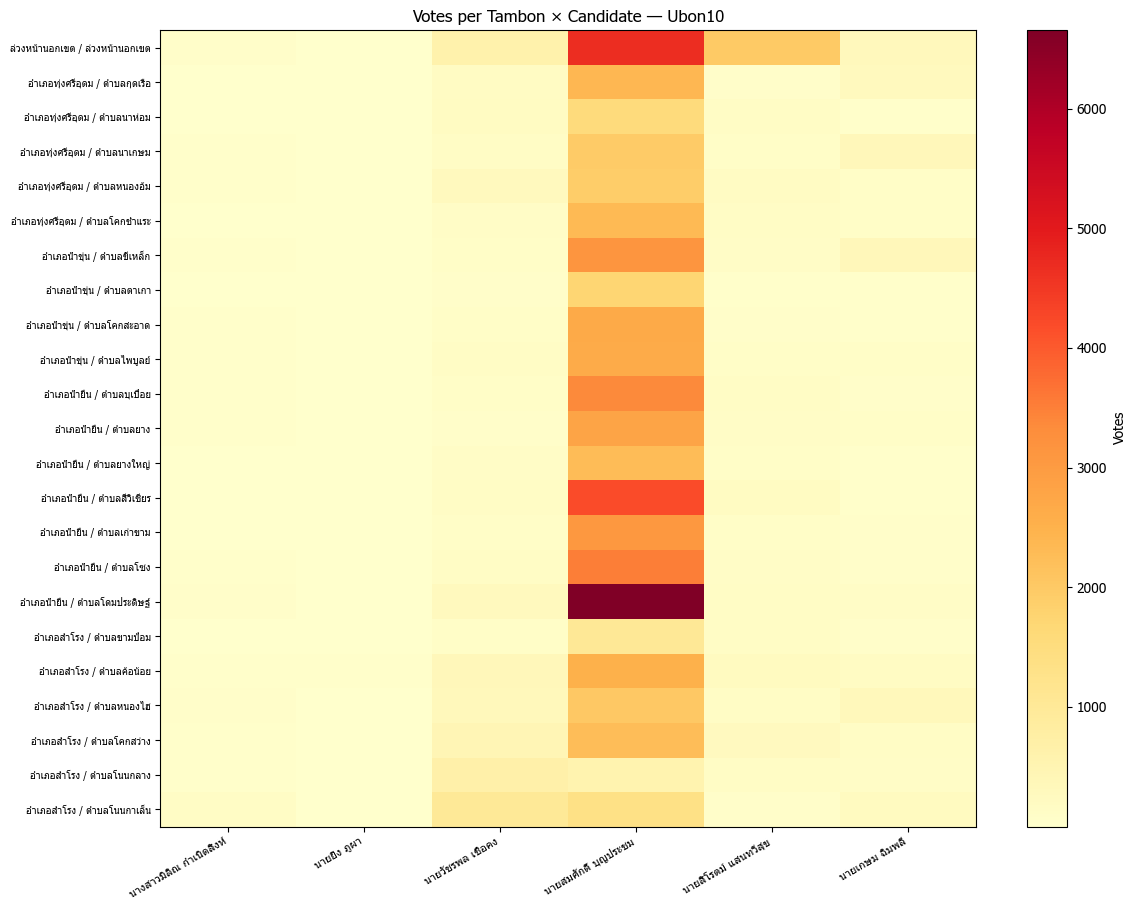

In [26]:
# Heatmap: score per (tambon × candidate)
pivot = const_by_tambon.pivot_table(
    index=['amphoe', 'tambon'],
    columns='candidate_name',
    values='score',
    aggfunc='sum'
).fillna(0)

fig, ax = plt.subplots(figsize=(12, max(6, len(pivot) * 0.4)))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=30, ha='right', fontsize=8)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f"{a} / {t}" for a, t in pivot.index], fontsize=7)

plt.colorbar(im, ax=ax, label='Votes')
ax.set_title('Votes per Tambon × Candidate — Ubon10')
plt.tight_layout()
plt.savefig(FIG / 'heatmap_tambon_candidate.png', dpi=150)
plt.show()

## 4 · Margin of Victory per Amphoe

In [27]:
# Margin = 1st place score - 2nd place score
def margin_of_victory(group):
    sorted_scores = group['score'].sort_values(ascending=False).values
    if len(sorted_scores) < 2:
        return pd.Series({'winner': group.loc[group['score'].idxmax(), 'candidate_name'],
                          'winner_party': group.loc[group['score'].idxmax(), 'party_name'],
                          'winner_score': sorted_scores[0],
                          'runner_up_score': 0,
                          'margin': sorted_scores[0],
                          'margin_%': 100.0})
    winner_row   = group.loc[group['score'].idxmax()]
    runner_score = sorted_scores[1]
    total_votes  = group['score'].sum()
    return pd.Series({
        'winner':         winner_row['candidate_name'],
        'winner_party':   winner_row['party_name'],
        'winner_score':   sorted_scores[0],
        'runner_up_score': runner_score,
        'margin':         sorted_scores[0] - runner_score,
        'margin_%':       round((sorted_scores[0] - runner_score) / total_votes * 100, 2),
    })

margins = (
    const_by_amphoe
    .groupby('amphoe')
    .apply(margin_of_victory)
    .reset_index()
    .sort_values('margin_%', ascending=False)
)

print('=== Margin of Victory per Amphoe ===')
print(margins[['amphoe', 'winner', 'winner_party', 'margin', 'margin_%']].to_string(index=False))

=== Margin of Victory per Amphoe ===
          amphoe               winner   winner_party  margin  margin_%
     อำเภอน้ำยืน นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง   24967     87.65
    อำเภอน้ำขุ่น นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง    9664     83.63
อำเภอทุ่งศรีอุดม นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง    9241     72.88
      อำเภอสำโรง นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง    6842     45.78
  ล่วงหน้านอกเขต นายสมศักดิ์ บุญประชม เพื่อไทรวมพลัง    2680     35.14


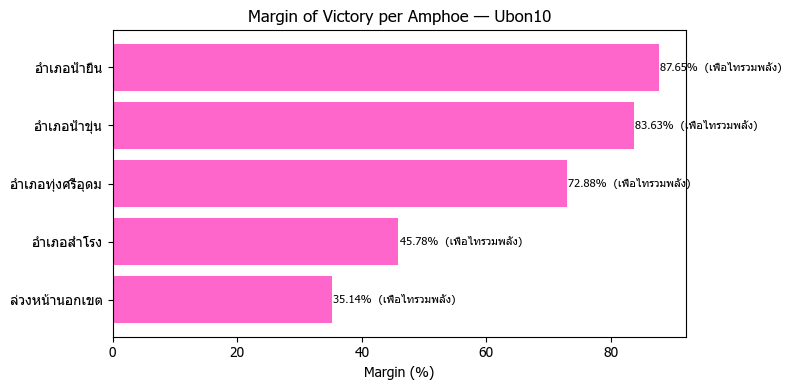

In [28]:
fig, ax = plt.subplots(figsize=(8, 4))

colors = [
    color_map.get(p, '#cccccc')
    for p in margins['winner_party']
]

ax.barh(margins['amphoe'], margins['margin_%'], color=colors)
ax.set_xlabel('Margin (%)')
ax.set_title('Margin of Victory per Amphoe — Ubon10')

for i, (_, row) in enumerate(margins.iterrows()):
    ax.text(row['margin_%'] + 0.3, i,
            f"{row['margin_%']}%  ({row['winner_party']})",
            va='center', fontsize=8)

ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG / 'margin_by_amphoe.png', dpi=150)
plt.show()

## 5 · Export Supplementary Tables

In [31]:
total.to_csv(OUT / 'const_overall.csv', index=False, encoding='utf-8-sig')
winner_per_amphoe.to_csv(OUT / 'const_winner_amphoe.csv', index=False, encoding='utf-8-sig')
winner_per_tambon.to_csv(OUT / 'const_winner_tambon.csv', index=False, encoding='utf-8-sig')
margins.to_csv(OUT / 'const_margin_amphoe.csv', index=False, encoding='utf-8-sig')
const_by_amphoe.to_csv(OUT / 'constituency_by_amphoe.csv', index=False, encoding='utf-8-sig')  # updated with vote_share

print('Exported OK')

Exported OK


## Summary

| File | Description |
|------|-------------|
| `const_overall.csv` | Overall scores + vote share per candidate |
| `const_winner_amphoe.csv` | Winner per amphoe |
| `const_winner_tambon.csv` | Winner per tambon |
| `const_margin_amphoe.csv` | Margin of victory per amphoe |
| `constituency_by_amphoe.csv` | Updated with vote_share_% column |

**Next:** `03_split_ticket.ipynb`